In [1]:
import matplotlib.pyplot as plt
import numpy
import scipy
import sys
sys.path.append('Models')
import Ionization.Ionization as Ionization
import Chemistry.Chemistry as Chemistry
import datetime
import IRI2016
import matplotlib


In [2]:
" instantiate the specific model classes"
ionization = Ionization.Ionization('config.cfg')
iri2016 = IRI2016.IRI2016()
chem = Chemistry.Chemistry('config.cfg')

In [3]:
"""
Generate the altitude grid and also setting up the time
"""
AltMinKm = 60.
AltMaxKm = 150.
AltStepKm = 1.0
altkm = numpy.arange(AltMinKm,AltMaxKm,AltStepKm)

t1970 = datetime.datetime(1970,1,1,0,0,0)
t2010 = datetime.datetime(2018,5,8,5,0,0)#datetime.datetime(2010,1,2,10,0,0)
tUnix = (t2010-t1970).total_seconds()

# location of poker flat research range
glat = 65.1256
glon = (360.-147.4919) # should be between 0-360 degrees

In [4]:
"""
Setting the background - this step must be run.
"""

chem.Set_Inital_Ionization(tUnix,glat,glon,AltMinKm,AltMaxKm,AltStepKm)

2018-05-08 01:00:00
*** IRI parameters are being calculated ***
Ne: IRI-2001 for Topside
Ne, foF2: CCIR model is used.
Ne: B0,B1 Bil-2000
Ne, foF1: probability function used.
Ne, D: IRI1990
Ne, foF2: storm model included
Ion Com.: DS-95 & DY-85
Te: Aeros/AE/ISIS model
Auroral boundary model on
Ne, foE: storm model on
[           nan            nan            nan            nan
            nan 6.36494880e+07 7.91145120e+07 9.65079200e+07
 1.15661696e+08 1.36335744e+08 1.58233136e+08 1.81019984e+08
 2.04348304e+08 2.27879264e+08 2.51305360e+08 2.74369536e+08
 2.96880064e+08 3.18721376e+08 3.39860128e+08 3.60348000e+08
 3.80321344e+08 4.00000000e+08 4.23071104e+08 4.68956000e+08
 5.72304256e+08 8.07809152e+08 1.35493261e+09 2.27360026e+09
 3.64822835e+09 5.60959078e+09 8.28262758e+09 1.17678285e+10
 1.61218683e+10 2.13413048e+10 2.73530266e+10 3.40138783e+10
 4.11203666e+10 4.84268810e+10 5.56696781e+10 6.25924669e+10
 6.89698734e+10 7.46255155e+10 7.94430341e+10 8.33694925e+10
 8.6412279

/Users/srkaeppler/research/data/pygpi5_dev/pyGPI5/Models/test062026/lib/python3.14/site-packages/scipy/integrate/_ode.py:438: UserWarning: vode: Excess work done on this call. (Perhaps wrong MF.)
  self._y, self.t = mth(self.f, self.jac or (lambda: None),


In [5]:
chem.DregionChem.keys()

dict_keys(['alphaD', 'alphaDC', 'alphaI', 'beta', 'B', 'gamma', 'gammaX', 'Xbar'])

In [ ]:
print(chem.DregionChem['alphaD'])

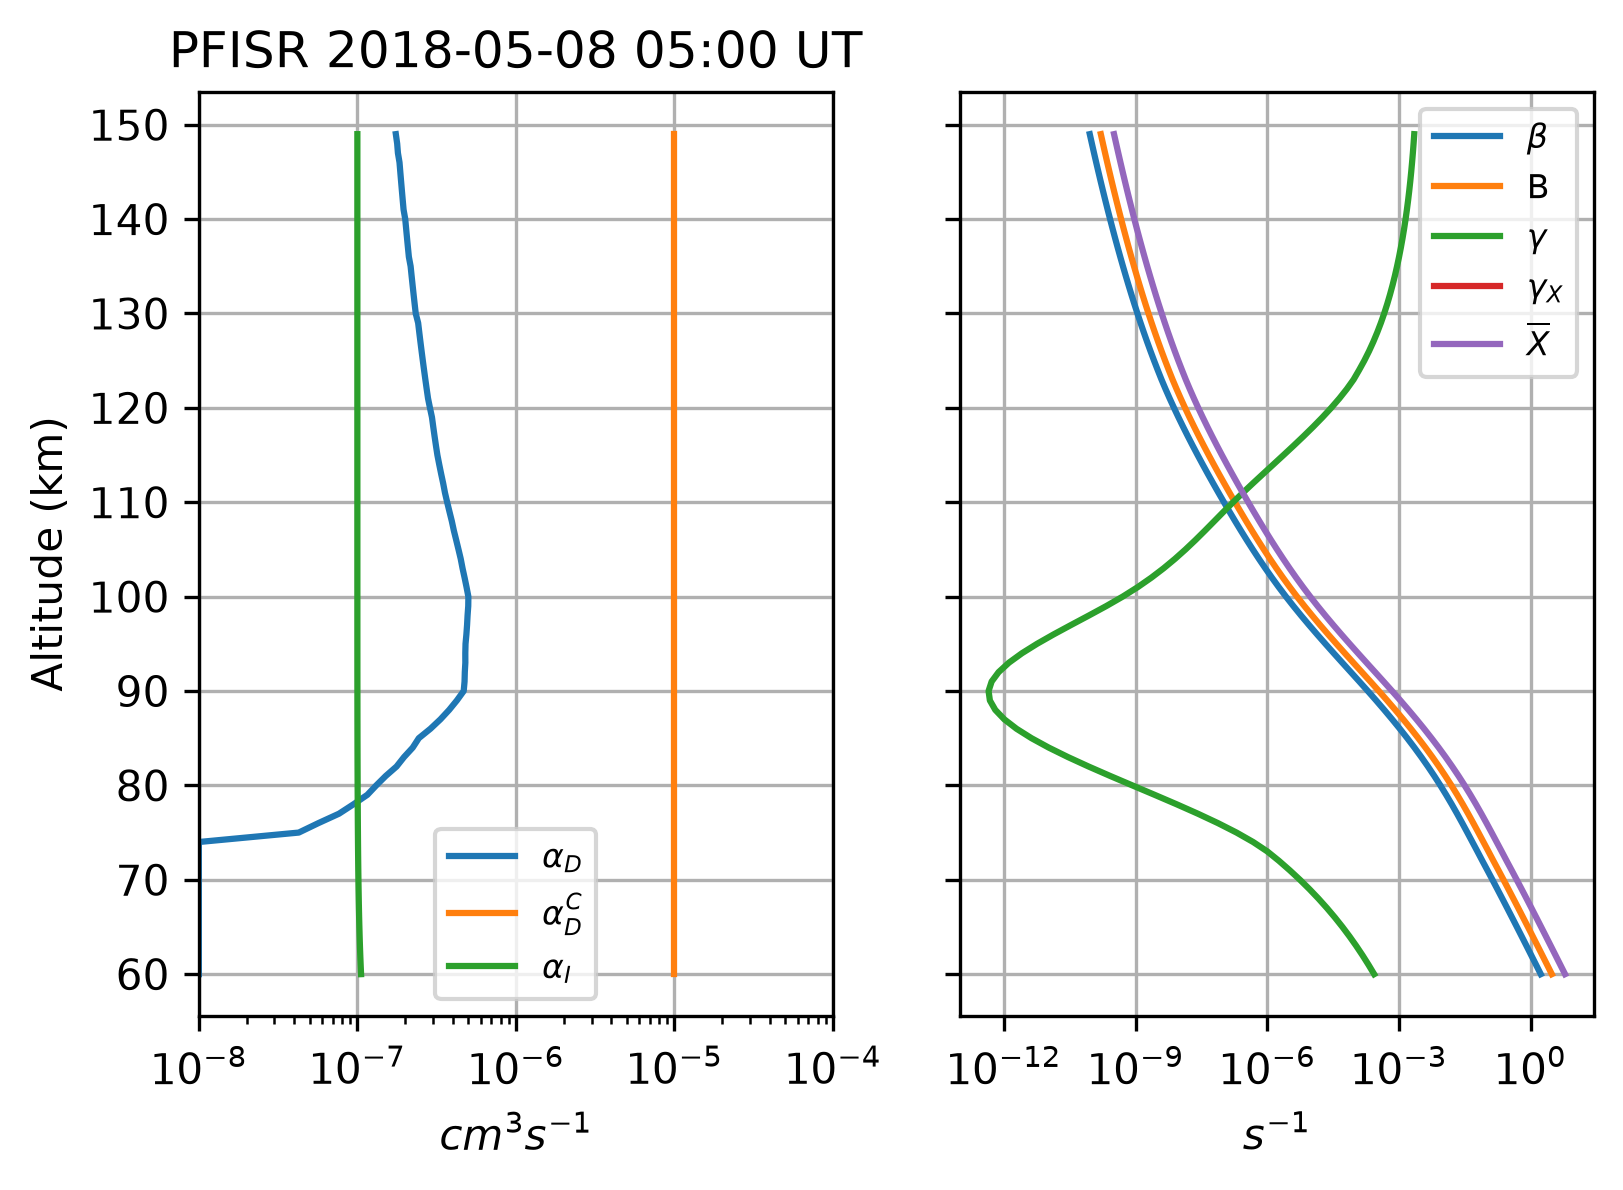

In [6]:

f,ax = plt.subplots(1,2, sharey=True, dpi=300, figsize=(6,4),facecolor="w")
# plt.figure(dpi=300)
ax[0].semilogx(chem.DregionChem['alphaD'], chem.altkm, label=r'$\alpha_{D}$')
ax[0].semilogx(chem.DregionChem['alphaDC'], chem.altkm, label=r'$\alpha_{D}^{C}$')
ax[0].semilogx(chem.DregionChem['alphaI'], chem.altkm, label=r'$\alpha_{I}$')
ax[0].legend(prop={'size': 8})
ax[0].set_yticks([60,70,80,90,100,110,120,130,140,150])
ax[0].set_xlim([1e-8,1e-4])
ax[0].set_xlabel(r'$cm^{3}s^{-1}$')
ax[0].set_ylabel('Altitude (km)')
ax[0].grid()

ax[1].semilogx(chem.DregionChem['beta'], chem.altkm, label=r'$\beta$')
ax[1].semilogx(chem.DregionChem['B'], chem.altkm, label='B')
ax[1].semilogx(chem.DregionChem['gamma'], chem.altkm, label=r'$\gamma$')
ax[1].semilogx(chem.DregionChem['gammaX'], chem.altkm, label=r'$\gamma_{X}$')
ax[1].semilogx(chem.DregionChem['Xbar'], chem.altkm, label = r'$\overline{X}$')
ax[1].legend(prop={'size': 8})
ax[1].set_yticks([60,70,80,90,100,110,120,130,140,150])
ax[1].set_xlabel(r'$s^{-1}$')
ax[1].grid()

ax[0].set_title('PFISR 2018-05-08 05:00 UT')
plt.subplots_adjust(hspace=0)
# plt.savefig('Figure1_test.png',bbox_inches='tight')

In [ ]:
chem.y0.keys()

([<matplotlib.axis.YTick at 0x10f2f5090>,
 [Text(0, 60, '60'),
  Text(0, 70, '70'),
  Text(0, 80, '80'),
  Text(0, 90, '90'),
  Text(0, 100, '100'),
  Text(0, 110, '110'),
  Text(0, 120, '120'),
  Text(0, 130, '130'),
  Text(0, 140, '140'),
  Text(0, 150, '150')])

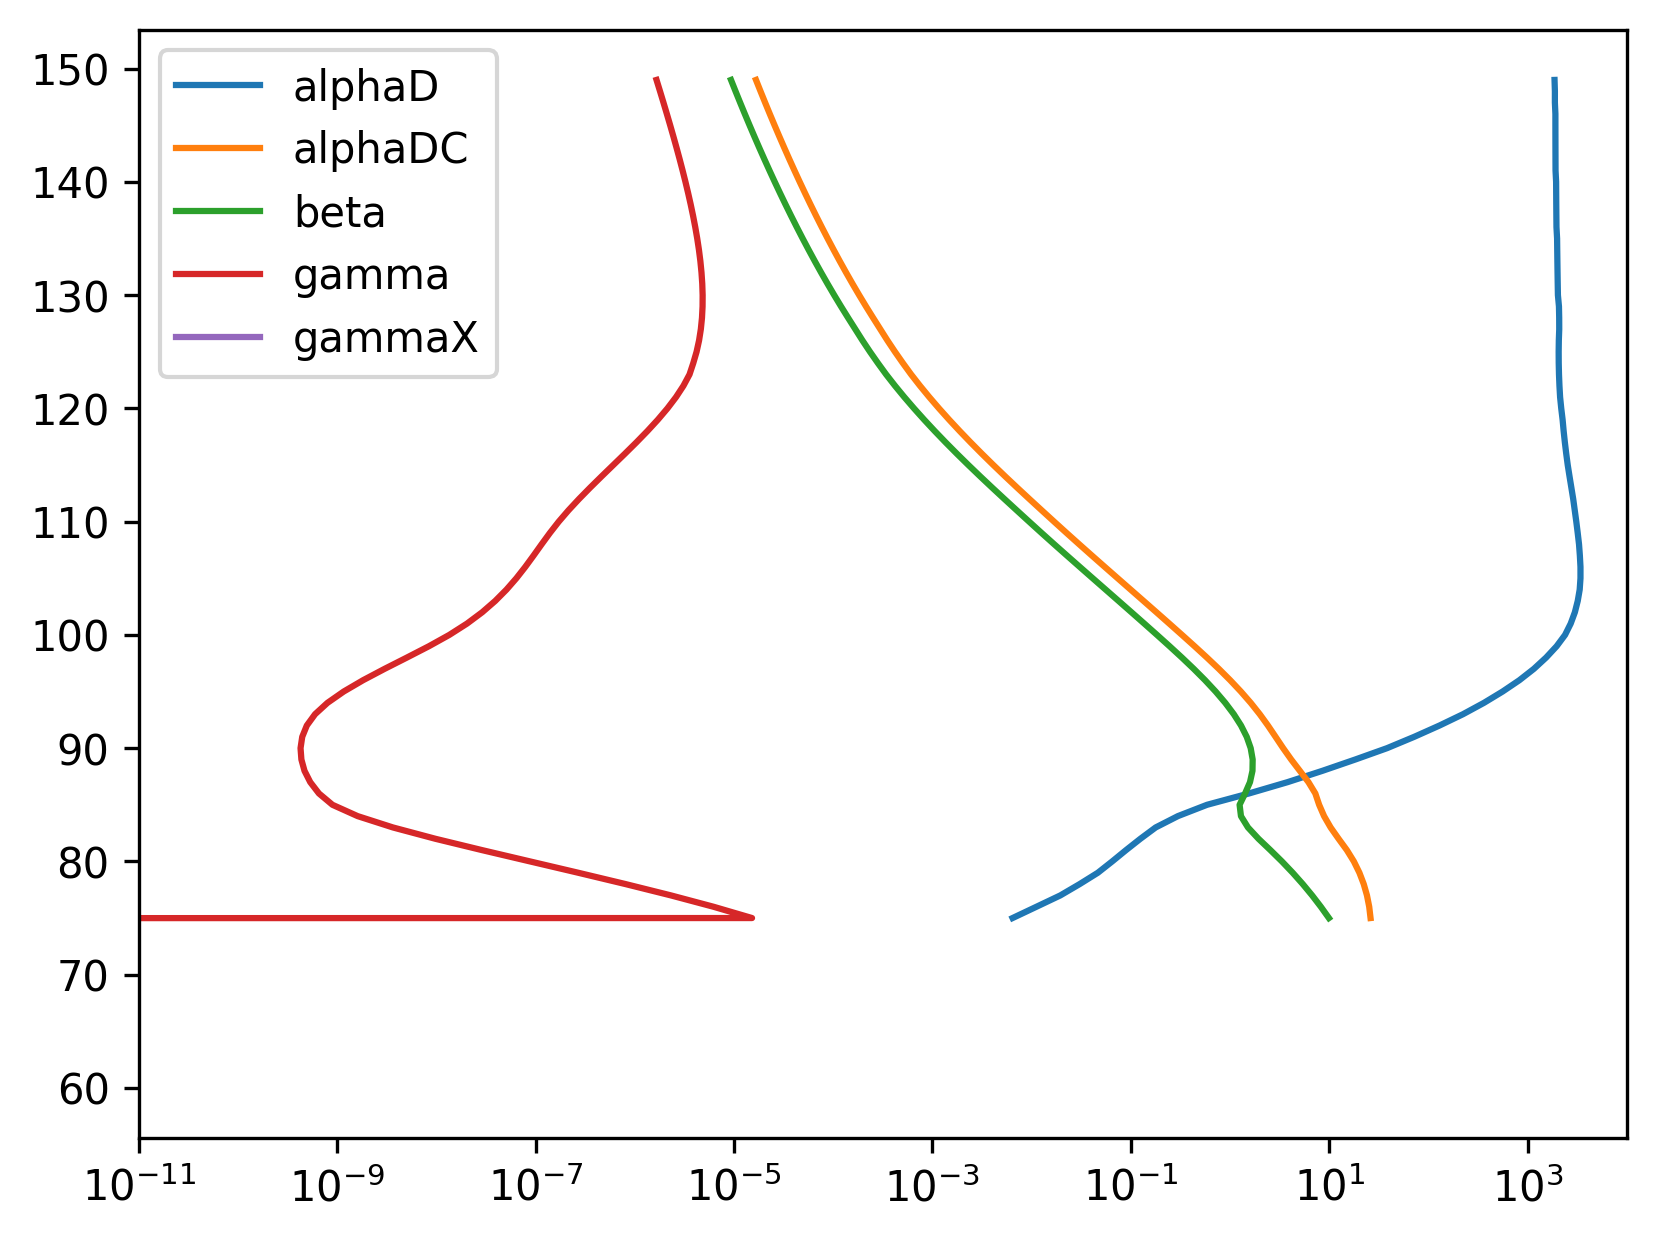

In [7]:
plt.figure(dpi=300)
plt.semilogx(chem.DregionChem['alphaD']*chem.y0['Ne']*chem.y0['NposIon'], chem.altkm, label='alphaD')
plt.semilogx(chem.DregionChem['alphaDC']*chem.y0['Ne']*chem.y0['NposCluster'], chem.altkm, label='alphaDC')
# plt.semilogx(chem.DregionChem['alphaI'], chem.altkm, label='alphaI')
plt.semilogx(chem.DregionChem['beta']*chem.y0['Ne'], chem.altkm, label='beta')
# plt.semilogx(chem.DregionChem['B'], chem.altkm, label='B')
plt.semilogx(chem.DregionChem['gamma']*chem.y0['NnegIon'], chem.altkm, label='gamma')
plt.semilogx(chem.DregionChem['gammaX']*chem.y0['NX'], chem.altkm, label='gammaX')
# plt.semilogx(chem.DregionChem['Xbar'], chem.altkm, label = 'Xbar')
plt.legend()
plt.xlim([1e-11,1e4])
plt.yticks([60,70,80,90,100,110,120,130,140,150])

(1, 100000.0)

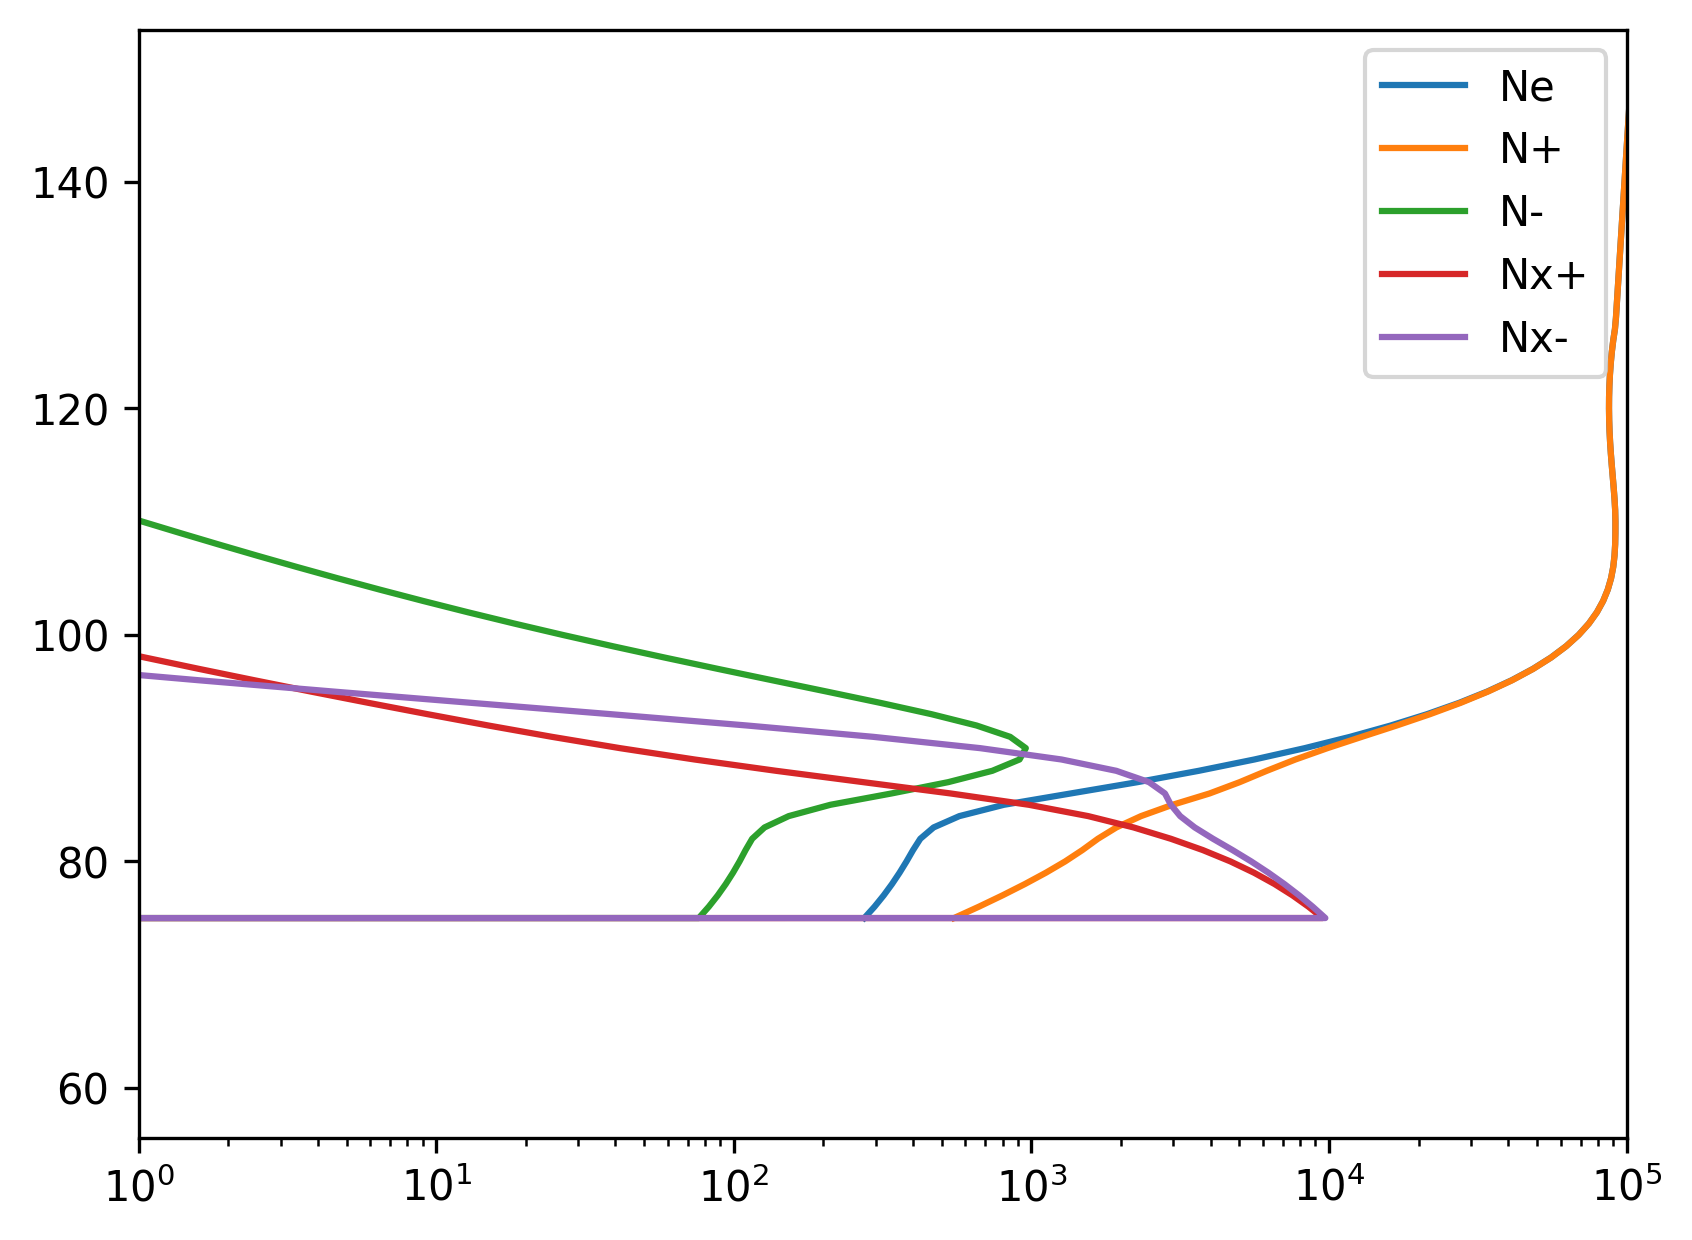

In [8]:
plt.figure(dpi=300)
plt.semilogx(chem.y0['Ne'], chem.altkm, label='Ne')
plt.semilogx(chem.y0['NposIon'], chem.altkm, label = 'N+')
plt.semilogx(chem.y0['NnegIon'], chem.altkm, label = 'N-')
plt.semilogx(chem.y0['NposCluster'], chem.altkm, label='Nx+')
plt.semilogx(chem.y0['NX'], chem.altkm, label='Nx-')
plt.legend()
plt.xlim([1,1e5])

In [9]:
EeV = numpy.array([10000.]) # eV
QeV = numpy.array([1.]) # mW/m^2
qZ, qZE,qfoo = ionization.Ionization(EeV,QeV,AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon)
qZ[qZ<1e-2] = 1e-2

365


365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365
365


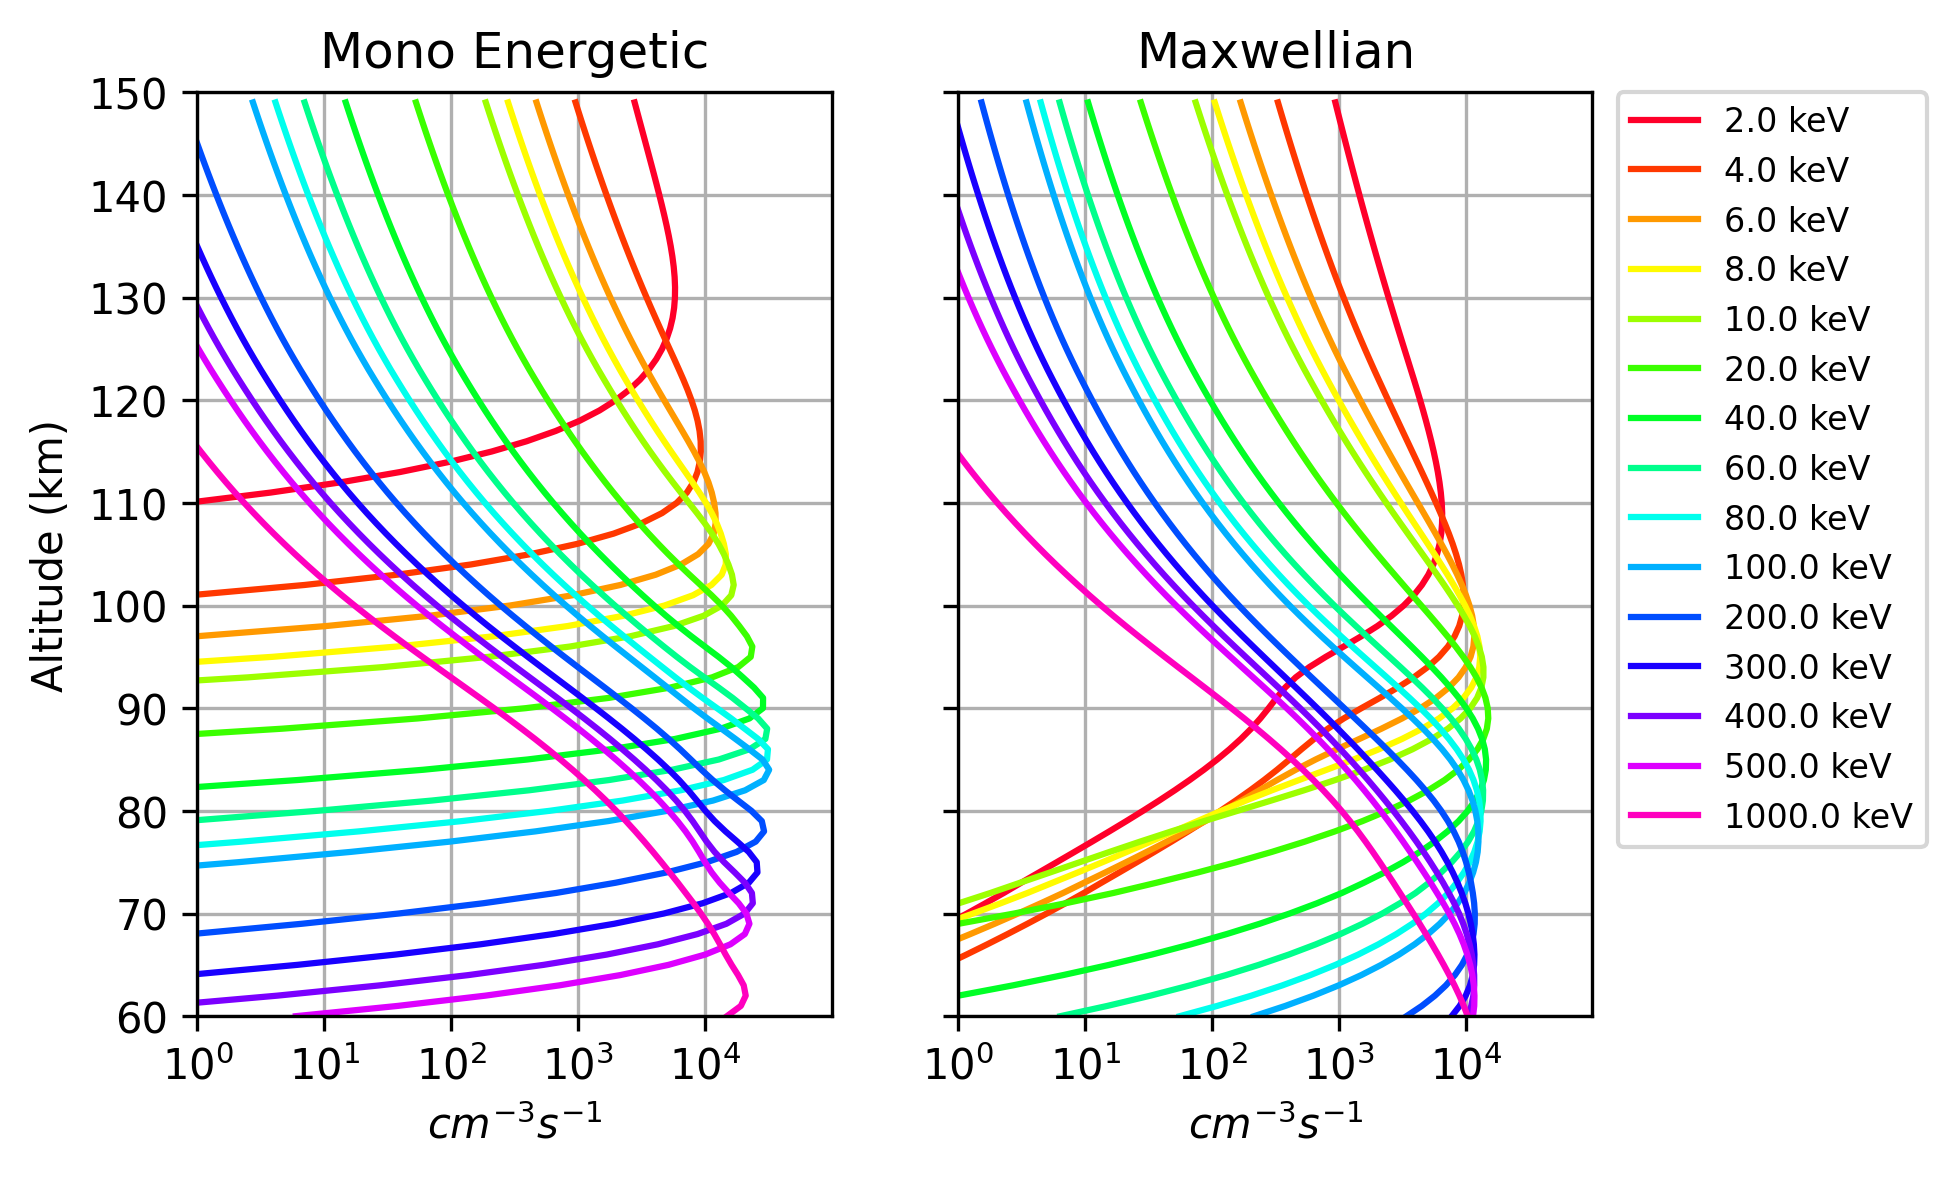

In [10]:
f,ax = plt.subplots(1,2, sharey=True, dpi=300, figsize=(6,4),facecolor="w")

EeV = numpy.array([2.,4.,6.,8.,10.,20.,40.,60.,80.,100.,200.,300.,400.,500.,1000.])*1000.
QeV = numpy.array([1.]) # mW/m^2

# ncolors = numpy.arange(1, EeV.shape[0]+1)
color = plt.cm.gist_rainbow(numpy.linspace(0, 1, EeV.shape[0]))

k = 0
for iEnergy in EeV:
    qZ, qZE,qfoo = ionization.Ionization(numpy.array([iEnergy]),QeV,AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon)
    qZ[qZ<1e-2] = 1e-2
    ax[0].semilogx(qZ, chem.altkm, color=color[k],label='%s keV'%(iEnergy/1000.))
    k=k+1
ax[0].set_xlim([1,1e5])
# ax[0].legend(prop={'size': 6})
ax[0].set_ylim([60,150])
ax[0].set_yticks([60,70,80,90,100,110,120,130,140,150])
ax[0].set_ylabel('Altitude (km)')
ax[0].set_title('Mono Energetic')
ax[0].set_xlabel(r'$cm^{-3} s^{-1}$')
ax[0].set_xticks([1,1e1,1e2,1e3,1e4])
ax[0].grid()


del qZ
k = 0
for iEnergy in EeV:
    qZ, qZE,qfoo = ionization.Ionization(numpy.array([iEnergy]),QeV,AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon, IonizationType='Maxwellian')
    qZ[qZ<1e-2] = 1e-2
    ax[1].semilogx(qZ, chem.altkm, color=color[k], label='%s keV'%(iEnergy/1000.))
    k=k+1
ax[1].set_xlim([1,1e5])
# ax[1].legend(prop={'size': 6})
ax[1].set_ylim([60,150])
ax[1].set_yticks([60,70,80,90,100,110,120,130,140,150])
ax[1].set_title('Maxwellian')
ax[1].set_xticks([1,1e1,1e2,1e3,1e4])
ax[1].set_xlabel(r'$cm^{-3} s^{-1}$')
ax[1].grid()

ax[1].legend(prop={'size': 8},bbox_to_anchor=(1.04,1), borderaxespad=0)
# plt.savefig('Figure2_test.png',bbox_inches='tight')

In [ ]:
plt.figure(dpi=300)

EeV = numpy.array([2.,4.,6.,8.,10.,20.,40.,60.,80.,100.,200.,300.,400.,500.,1000.])*1000.
QeV = numpy.array([1.]) # mW/m^2

# ncolors = numpy.arange(1, EeV.shape[0]+1)
color = plt.cm.plasma(numpy.linspace(0, 1, EeV.shape[0]))

k = 0
for iEnergy in EeV:
    qZ, qZE,qfoo = ionization.Ionization(numpy.array([iEnergy]),QeV,AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon, IonizationType='Maxwellian')
    qZ[qZ<1e-2] = 1e-2
    plt.semilogx(qZ, chem.altkm, color=color[k], 
    k=k+1
plt.xlim([1,1e5])

In [ ]:
EeV = numpy.array([300000.]) # eV
QeV = numpy.array([1.]) # mW/m^2
qZ, qZE,qfoo = ionization.Ionization(EeV,QeV,AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon)
qZ[qZ<1e-2] = 1e-2

ChemOut = chem(qZ,chem.altkm, IntegrationTime = 1.)


f, ax = plt.subplots(1,2, sharey=True, dpi=300, figsize=(6,4),facecolor="w")

ax[0].semilogx(chem.y0['Ne'], chem.altkm, label=r'$n_{e}$')
ax[0].semilogx(chem.y0['NposIon'], chem.altkm, label = r'$n^{+}$')
ax[0].semilogx(chem.y0['NnegIon'], chem.altkm, label = r'$n^{-}$')
ax[0].semilogx(chem.y0['NposCluster'], chem.altkm, label=r'$n_{x}^{+}$')
ax[0].semilogx(chem.y0['NX'], chem.altkm, label=r'$n_{x}^{-}$')

ax[1].semilogx(ChemOut['Ne'], chem.altkm, label=r'$n_{e}$')
ax[1].semilogx(ChemOut['NposIon'], chem.altkm, label = r'$n^{+}$')
ax[1].semilogx(ChemOut['NnegIon'], chem.altkm, label = r'$n^{-}$')
ax[1].semilogx(ChemOut['NposCluster'], chem.altkm, label=r'$n_{x}^{+}$')
ax[1].semilogx(ChemOut['NX'], chem.altkm, label=r'$n_{x}^{-}$')
ax[1].legend()
ax[0].legend()
ax[1].set_xlim([1e-5,1e6])
ax[0].set_xlim([1e-5,1e6])

ax[0].set_title('PFISR 2018-05-08 05:00 UT' + '\n' + 'Background')
ax[1].set_title(r'$Q = 1 mW/m^{2}$, $E = 300 keV$,'+'\n'+'IntTime = 1s')
ax[0].set_ylabel('Altitude (km)')
ax[0].set_xlabel(r'$cm^{-3}$')
ax[1].set_xlabel(r'$cm^{-3}$')
ax[0].grid()
ax[1].grid()

plt.savefig('Figure3_test.png',bbox_inches='tight')


# plt.semilogx(qZ, chem.altkm)


In [ ]:
EeV = numpy.array([300000.]) # eV
QeV = numpy.array([1.]) # mW/m^2
qZ, qZE,qfoo = ionization.Ionization(EeV,QeV,AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon)
qZ[qZ<1e-2] = 1e-2


ChemOut0 = chem(qZ,chem.altkm, IntegrationTime = 0.01)
ChemOut1 = chem(qZ,chem.altkm, IntegrationTime = 0.1)
ChemOut2 = chem(qZ,chem.altkm, IntegrationTime = 1.0)
ChemOut3 = chem(qZ,chem.altkm, IntegrationTime = 5.0)
ChemOut4 = chem(qZ,chem.altkm, IntegrationTime = 10.0)
ChemOut5 = chem(qZ,chem.altkm, IntegrationTime = 60.0)
ChemOut6 = chem(qZ,chem.altkm, IntegrationTime = 300.0)

EeV = numpy.array([50000.]) # eV
QeV = numpy.array([1.]) # mW/m^2
qZ, qZE,qfoo = ionization.Ionization(EeV,QeV,AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon)
qZ[qZ<1e-2] = 1e-2

ChemOut7 = chem(qZ,chem.altkm, IntegrationTime = 0.1)
ChemOut8 = chem(qZ,chem.altkm, IntegrationTime = 1.0)
ChemOut9 = chem(qZ,chem.altkm, IntegrationTime = 5.0)
ChemOut10 = chem(qZ,chem.altkm, IntegrationTime = 10.0)
ChemOut11 = chem(qZ,chem.altkm, IntegrationTime = 60.0)
ChemOut12 = chem(qZ,chem.altkm, IntegrationTime = 300.0)

EeV = numpy.array([10000.]) # eV
QeV = numpy.array([1.]) # mW/m^2
qZ, qZE,qfoo = ionization.Ionization(EeV,QeV,AltMinKm,AltMaxKm,AltStepKm,tUnix,glat,glon)
qZ[qZ<1e-2] = 1e-2

ChemOut13 = chem(qZ,chem.altkm, IntegrationTime = 0.1)
ChemOut14 = chem(qZ,chem.altkm, IntegrationTime = 1.0)
ChemOut15 = chem(qZ,chem.altkm, IntegrationTime = 5.0)
ChemOut16 = chem(qZ,chem.altkm, IntegrationTime = 10.0)
ChemOut17 = chem(qZ,chem.altkm, IntegrationTime = 60.0)
ChemOut18 = chem(qZ,chem.altkm, IntegrationTime = 300.0)


In [ ]:
f, ax = plt.subplots(1,3, sharey=True, dpi=300, figsize=(6,4),facecolor="w")

ax[0].semilogx(ChemOut0['Ne'], chem.altkm, label=r'0.01s', color='purple')
ax[0].semilogx(ChemOut1['Ne'], chem.altkm, label=r'0.1s', color='blue')
ax[0].semilogx(ChemOut2['Ne'], chem.altkm, label=r'1.0s', color = 'green')
ax[0].semilogx(ChemOut3['Ne'], chem.altkm, label=r'5.0s', color = 'orange')
ax[0].semilogx(ChemOut4['Ne'], chem.altkm, label=r'10s', color='red')
ax[0].semilogx(ChemOut5['Ne'], chem.altkm, label=r'60s', color = 'magenta')
ax[0].semilogx(ChemOut6['Ne'], chem.altkm, label=r'300s', color = 'black')
ax[0].legend(prop={'size': 8})
ax[0].set_title('300 KeV')
ax[0].set_ylabel('Altitude (km)')
ax[0].set_xlabel(r'$n_{e} (cm^{-3})$')
ax[0].grid()

ax[1].semilogx(ChemOut7['Ne'], chem.altkm, label=r'0.1s', color='blue')
ax[1].semilogx(ChemOut8['Ne'], chem.altkm, label=r'1.0s', color = 'green')
ax[1].semilogx(ChemOut9['Ne'], chem.altkm, label=r'5.0s', color = 'orange')
ax[1].semilogx(ChemOut10['Ne'], chem.altkm, label=r'10s', color = 'red')
ax[1].semilogx(ChemOut11['Ne'], chem.altkm, label=r'60s', color = 'magenta')
ax[1].semilogx(ChemOut12['Ne'], chem.altkm, label=r'300s', color = 'black')
ax[1].legend(prop={'size': 8})
ax[1].set_title('50 KeV')
ax[1].set_xlabel(r'$n_{e} (cm^{-3})$')
ax[1].grid()


ax[2].semilogx(ChemOut13['Ne'], chem.altkm, label=r'0.1s', color='blue')
ax[2].semilogx(ChemOut14['Ne'], chem.altkm, label=r'1.0s', color = 'green')
ax[2].semilogx(ChemOut15['Ne'], chem.altkm, label=r'5.0s', color = 'orange')
ax[2].semilogx(ChemOut16['Ne'], chem.altkm, label=r'10s', color = 'red')
ax[2].semilogx(ChemOut17['Ne'], chem.altkm, label=r'60s', color = 'magenta')
ax[2].semilogx(ChemOut18['Ne'], chem.altkm, label=r'300s', color = 'black')
ax[2].legend(prop={'size': 8})
ax[2].set_title('10 KeV')
ax[2].set_xlabel(r'$n_{e} (cm^{-3})$')
ax[2].grid()

ax[0].set_xlim([1e2,1e6])
ax[1].set_xlim([1e2,1e6])
ax[2].set_xlim([1e2,1e6])

ax[0].set_ylim([60,150])
ax[1].set_ylim([60,150])
ax[2].set_ylim([60,150])

ax[0].set_xticks([1e2,1e3,1e4,1e5,1e6])
ax[1].set_xticks([1e2,1e3,1e4,1e5,1e6])
ax[2].set_xticks([1e2,1e3,1e4,1e5,1e6])
plt.savefig('Figure4_test.png',bbox_inches='tight')

In [ ]:
#time evolution, maybe turn on and then turn off